# 06b · Identification — can we recover a *causal* price elasticity?

Notebook 06 showed the naive occupancy–real-rate slope is positive/zero:
reverse causality (hotels price into strong demand) and omitted seasonal-demand
shocks dominate. Before falling back to assumed-elasticity scenarios in nb07,
this notebook tries four identification strategies:

| # | Strategy | Removes | Identifying variation |
|---|---|---|---|
| A | **Year-on-year (12-month) differences** | fixed monthly seasonality | YoY change in real rate vs YoY change in occupancy |
| B | **Relative-price panel** (tier vs cross-tier mean, month + category FE) | *all* city-wide monthly demand shocks (FX, events, season, macro) | how a tier's occupancy moves when its price moves **relative to the other tiers** that month |
| C | **2SLS** with operating-cost instruments (housing/utilities & restaurants-&-hotels CPI relative to headline) | demand-driven price variation | cost-push component of the real rate |
| D | **Predetermined price** (only `ln_rr_{t-1}`, `_{t-2}`) | simultaneity with the current-month demand shock | last months' price setting |

**Verdict rule:** carry a data-anchored elasticity into nb07 only if a strategy
that plausibly breaks the endogeneity (B or C) delivers a **negative,
significant** β in a sane range (roughly −0.15 to −2.5) with a non-weak first
stage. Otherwise nb07 uses a literature scenario grid and we report that
identification failed.

**Inputs** `03_analysis_panel.parquet`, `01_loaded/cpi.parquet` →
**Output** `outputs/tables/identification_summary.csv`, `outputs/figures/06b_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("06b_ident")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
df = df[(df.in_window == 1) & (df.covid_any == 0)].copy()
CORE = C.CORE_CATEGORIES
ALLc = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
MONTHS = [f"m{m:02d}" for m in range(2, 13)]
HAC = dict(cov_type="HAC", cov_kwds={"maxlags": 6})

# extra CPI divisions for the cost instruments (GBA region)
craw = pd.read_parquet(C.P_LOADED_DIR / "cpi.parquet")
craw = craw[(craw.src_sheet == "index_national") & (craw.region == "gba")]
piv = craw.pivot_table(index="date", columns="series", values="value")
cost = pd.DataFrame(index=piv.index)
cost["rel_vivienda"] = np.log(piv["Vivienda, agua, electricidad, gas y otros combustibles"] /
                              piv["Nivel general"])
cost["rel_resthot"] = np.log(piv["Restaurantes y hoteles"] / piv["Nivel general"])
cost = cost.reset_index()
df = df.merge(cost, on="date", how="left")

df["ln_occ"] = np.log(df["room_occupancy"])
df["ln_rr"] = np.log(df["real_rate_gba"])
df = df.sort_values(["hotel_category", "date"])
g = df.groupby("hotel_category", group_keys=False)
df["ln_occ_yoy"] = g["ln_occ"].apply(lambda s: s.diff(12))
df["ln_rr_yoy"] = g["ln_rr"].apply(lambda s: s.diff(12))
df["infl_yoy"] = df["infl_yoy_gba"]
df["ln_rr_l1"] = g["ln_rr"].apply(lambda s: s.shift(1))
df["ln_rr_l2"] = g["ln_rr"].apply(lambda s: s.shift(2))
df["rel_vivienda_l1"] = g["rel_vivienda"].apply(lambda s: s.shift(1))

## A · Year-on-year differences (seasonality removed by construction)

Overlapping 12-month differences → strong MA(12) autocorrelation, so HAC lags = 18.

In [2]:
rowsA = []
for cat in ALLc:
    s = df[df.hotel_category == cat].dropna(subset=["ln_occ_yoy", "ln_rr_yoy", "infl_yoy"])
    if len(s) < 24:
        continue
    X = sm.add_constant(s[["ln_rr_yoy", "infl_yoy", "t"]].astype(float))
    m = sm.OLS(s["ln_occ_yoy"].astype(float), X).fit(cov_type="HAC",
                                                     cov_kwds={"maxlags": 18})
    rowsA.append(dict(strategy="A_yoy_diff", hotel_category=cat, label=LAB[cat],
                      beta=round(m.params["ln_rr_yoy"], 3),
                      se=round(m.bse["ln_rr_yoy"], 3),
                      t=round(m.tvalues["ln_rr_yoy"], 2), n=int(m.nobs), fstage_F=np.nan))
resA = pd.DataFrame(rowsA)
resA

,strategy,hotel_category,label,beta,se,t,n,fstage_F
0,A_yoy_diff,stars_1_2,1-2 star,1.427,0.137,10.40,65,NaN
1,A_yoy_diff,stars_3,3 star,0.382,0.092,4.15,65,NaN
2,A_yoy_diff,stars_4,4 star,0.327,0.143,2.28,65,NaN
3,A_yoy_diff,stars_5,5 star,0.027,0.053,0.52,65,NaN
4,A_yoy_diff,apart,Apart-hotel,0.142,0.073,1.94,65,NaN
5,A_yoy_diff,boutique,Boutique,0.195,0.157,1.24,65,NaN


## B · Relative-price panel — month FE + category FE

`ln_occ` and `ln_rr` demeaned across the four star tiers each month, then
PanelOLS with entity (category) and time (month) effects and clustered SEs.
Common city-wide demand shocks are fully absorbed by the time effects; β is the
**within-month cross-tier** relationship.

In [3]:
p = df[df.hotel_category.isin(CORE)].copy()
mmean = p.groupby("date")[["ln_occ", "ln_rr"]].transform("mean")
p["ln_occ_dev"] = p["ln_occ"] - mmean["ln_occ"]
p["ln_rr_dev"] = p["ln_rr"] - mmean["ln_rr"]
p = p.dropna(subset=["ln_occ_dev", "ln_rr_dev"]).set_index(["hotel_category", "date"])

mB = PanelOLS.from_formula("ln_occ_dev ~ ln_rr_dev + EntityEffects + TimeEffects",
                           data=p).fit(cov_type="clustered", cluster_entity=True)
# also the un-demeaned version with the same FE (equivalent, as a check)
mB2 = PanelOLS.from_formula("ln_occ ~ ln_rr + EntityEffects + TimeEffects",
                            data=df[df.hotel_category.isin(CORE)]
                            .set_index(["hotel_category", "date"])).fit(
                                cov_type="clustered", cluster_entity=True)
resB = pd.DataFrame([
    dict(strategy="B_relative_price_FE", hotel_category="POOLED(core)", label="4 star tiers",
         beta=round(mB.params["ln_rr_dev"], 3), se=round(mB.std_errors["ln_rr_dev"], 3),
         t=round(mB.tstats["ln_rr_dev"], 2), n=int(mB.nobs), fstage_F=np.nan),
])
print(mB)
resB

                          PanelOLS Estimation Summary                           
Dep. Variable:             ln_occ_dev   R-squared:                        0.0053
Estimator:                   PanelOLS   R-squared (Between):              0.3736
No. Observations:                 308   R-squared (Within):               0.0053
Date:                Sun, Sep 06 2026   R-squared (Overall):              0.2636
Time:                        11:42:16   Log-likelihood                    328.90
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.2001
Entities:                           4   P-value                           0.2745
Avg Obs:                       77.000   Distribution:                   F(1,227)
Min Obs:                       77.000                                           
Max Obs:                       77.000   F-statistic (robust):             1.2840
                            

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


,strategy,hotel_category,label,beta,se,t,n,fstage_F
0,B_relative_price_FE,POOLED(core),4 star tiers,0.069,0.061,1.13,308,NaN


## C · 2SLS with operating-cost instruments

Endogenous: `ln_rr`. Instruments: lagged log relative price of **housing /
utilities** (`rel_vivienda_l1`) and **restaurants & hotels** (`rel_resthot`)
vs headline CPI — proxies for hotel operating-cost pressure. Exogenous controls:
inflation, trend, month dummies. First-stage F reported for weak-instrument
diagnosis (rule of thumb: F > 10).

In [4]:
rowsC = []
for cat in ALLc:
    s = df[df.hotel_category == cat].dropna(
        subset=["ln_occ", "ln_rr", "infl_mom_gba", "rel_resthot", "rel_vivienda_l1"] + MONTHS)
    if len(s) < 40:
        continue
    exog = sm.add_constant(s[["infl_mom_gba", "t"] + MONTHS].astype(float))
    iv = IV2SLS(s["ln_occ"].astype(float), exog, s[["ln_rr"]].astype(float),
                s[["rel_resthot", "rel_vivienda_l1"]].astype(float)).fit(cov_type="robust")
    fs = iv.first_stage.diagnostics.loc["ln_rr", "f.stat"]
    rowsC.append(dict(strategy="C_2sls_cost_iv", hotel_category=cat, label=LAB[cat],
                      beta=round(iv.params["ln_rr"], 3), se=round(iv.std_errors["ln_rr"], 3),
                      t=round(iv.tstats["ln_rr"], 2), n=int(iv.nobs),
                      fstage_F=round(float(fs), 1)))
resC = pd.DataFrame(rowsC)
resC

,strategy,hotel_category,label,beta,se,t,n,fstage_F
0,C_2sls_cost_iv,stars_1_2,1-2 star,0.899,0.560,1.61,75,6.8
1,C_2sls_cost_iv,stars_3,3 star,-0.868,0.847,-1.03,75,2.9
2,C_2sls_cost_iv,stars_4,4 star,-0.262,0.097,-2.70,75,140.0
3,C_2sls_cost_iv,stars_5,5 star,-0.074,0.078,-0.95,75,106.5
4,C_2sls_cost_iv,apart,Apart-hotel,-0.601,0.233,-2.59,75,20.1
5,C_2sls_cost_iv,boutique,Boutique,0.018,0.074,0.24,75,206.7


## D · Predetermined price (lags only, no contemporaneous rate)

In [5]:
rowsD = []
for cat in ALLc:
    s = df[df.hotel_category == cat].dropna(
        subset=["ln_occ", "ln_rr_l1", "ln_rr_l2", "infl_mom_gba"] + MONTHS)
    if len(s) < 40:
        continue
    X = sm.add_constant(s[["ln_rr_l1", "ln_rr_l2", "infl_mom_gba", "t"] + MONTHS].astype(float))
    m = sm.OLS(s["ln_occ"].astype(float), X).fit(**HAC)
    b = m.params["ln_rr_l1"] + m.params["ln_rr_l2"]
    cov = m.cov_params().loc[["ln_rr_l1", "ln_rr_l2"], ["ln_rr_l1", "ln_rr_l2"]]
    se = float(np.sqrt(np.ones(2) @ cov.values @ np.ones(2)))
    rowsD.append(dict(strategy="D_predetermined_lags", hotel_category=cat, label=LAB[cat],
                      beta=round(float(b), 3), se=round(se, 3), t=round(float(b / se), 2),
                      n=int(m.nobs), fstage_F=np.nan))
resD = pd.DataFrame(rowsD)
resD

,strategy,hotel_category,label,beta,se,t,n,fstage_F
0,D_predetermined_lags,stars_1_2,1-2 star,0.651,0.267,2.44,73,NaN
1,D_predetermined_lags,stars_3,3 star,0.242,0.125,1.94,73,NaN
2,D_predetermined_lags,stars_4,4 star,-0.045,0.074,-0.61,73,NaN
3,D_predetermined_lags,stars_5,5 star,-0.098,0.060,-1.62,73,NaN
4,D_predetermined_lags,apart,Apart-hotel,0.079,0.144,0.55,73,NaN
5,D_predetermined_lags,boutique,Boutique,0.030,0.058,0.51,73,NaN


## Summary & verdict

In [6]:
summ = pd.concat([resA, resB, resC, resD], ignore_index=True)
summ.to_csv(C.OUT_TAB / "identification_summary.csv", index=False)
LOG.log("write", "identification_summary.csv", len(summ))

# does any endogeneity-breaking strategy (B, C) give negative & significant β in range?
def credible(r):
    return (r["strategy"] in ("B_relative_price_FE", "C_2sls_cost_iv")
            and r["beta"] < 0 and abs(r["t"]) >= 1.96
            and -2.5 <= r["beta"] <= -0.10
            and (np.isnan(r["fstage_F"]) or r["fstage_F"] >= 10))

summ["credible_causal"] = summ.apply(credible, axis=1)
verdict = summ[summ.credible_causal]
LOG.log("verdict", "credible negative causal beta rows", len(verdict),
        "; ".join(f"{r.strategy}:{r.label}={r.beta}" for _, r in verdict.iterrows()) or "NONE")
print("VERDICT:", "data-anchored elasticity available ->" if len(verdict)
      else "identification did not deliver a usable causal beta -> nb07 uses scenario grid")
summ

  [06b_ident] write                  identification_summary.csv             19  
  [06b_ident] verdict                credible negative causal beta rows        2  C_2sls_cost_iv:4 star=-0.262; C_2sls_cost_iv:Apart-hotel=-0.601
VERDICT: data-anchored elasticity available ->


,strategy,hotel_category,label,beta,se,t,n,fstage_F,credible_causal
0,A_yoy_diff,stars_1_2,1-2 star,1.427,0.137,10.40,65,NaN,False
1,A_yoy_diff,stars_3,3 star,0.382,0.092,4.15,65,NaN,False
2,A_yoy_diff,stars_4,4 star,0.327,0.143,2.28,65,NaN,False
3,A_yoy_diff,stars_5,5 star,0.027,0.053,0.52,65,NaN,False
4,A_yoy_diff,apart,Apart-hotel,0.142,0.073,1.94,65,NaN,False
5,A_yoy_diff,boutique,Boutique,0.195,0.157,1.24,65,NaN,False
6,B_relative_price_FE,POOLED(core),4 star tiers,0.069,0.061,1.13,308,NaN,False
7,C_2sls_cost_iv,stars_1_2,1-2 star,0.899,0.560,1.61,75,6.8,False
8,C_2sls_cost_iv,stars_3,3 star,-0.868,0.847,-1.03,75,2.9,False
9,C_2sls_cost_iv,stars_4,4 star,-0.262,0.097,-2.70,75,140.0,True


## Chart — all identification estimates side by side

  [06b_ident] figure                 06b_identification.png                     


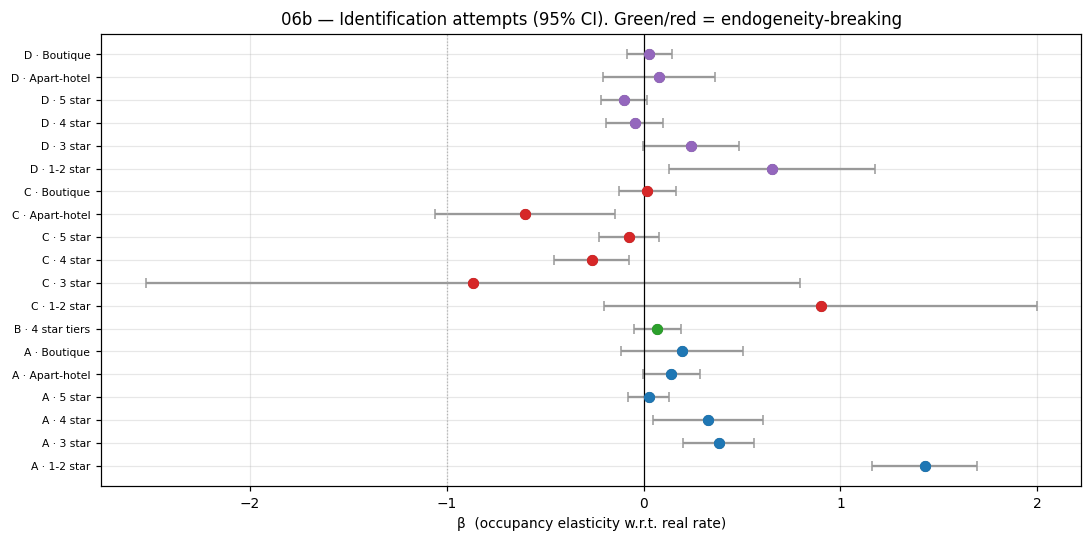

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
order = summ.reset_index(drop=True)
y = np.arange(len(order))
colors = {"A_yoy_diff": "tab:blue", "B_relative_price_FE": "tab:green",
          "C_2sls_cost_iv": "tab:red", "D_predetermined_lags": "tab:purple"}
ax.errorbar(order["beta"], y, xerr=1.96 * order["se"], fmt="o",
            ecolor="0.6", color="k", capsize=3)
for i, r in order.iterrows():
    ax.scatter(r["beta"], i, color=colors[r["strategy"]], zorder=3, s=40)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.strategy.split('_')[0]} · {r.label}" for _, r in order.iterrows()],
                   fontsize=7)
ax.axvline(0, color="k", lw=.8); ax.axvline(-1, color="0.7", ls=":", lw=.8)
ax.set_xlabel("β  (occupancy elasticity w.r.t. real rate)")
ax.set_title("06b — Identification attempts (95% CI). Green/red = endogeneity-breaking")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "06b_identification.png")
LOG.log("figure", "06b_identification.png"); plt.show()

In [8]:
LOG.flush()
print("06b complete.")

06b complete.
